In [1]:
# ============================================================
# SETUP: Configure paths and imports for reproducibility
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import sys

# Auto-detect repository root by walking up directories
_current = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_current, 'dcpbst_package')):
        break
    _current = os.path.dirname(_current)
else:
    _current = os.getcwd()

REPO_ROOT = _current
DATA_DIR = os.path.join(REPO_ROOT, 'data')
FIGURES_DIR = os.path.join(REPO_ROOT, 'figures')
RESULTS_DIR = os.path.join(REPO_ROOT, 'saved_results')
CONFIGS_DIR = os.path.join(REPO_ROOT, 'configs')

# Change to repo root so relative paths work
os.chdir(REPO_ROOT)

# Add dcpbst_package to import path
sys.path.insert(0, os.path.join(REPO_ROOT, 'dcpbst_package'))
print(f'Repo root: {REPO_ROOT}')
print(f'Data dir: {DATA_DIR}')

# Set random seeds for reproducibility
import numpy as np
import torch
import random
seed = 100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    device = 'cuda'
else:
    device = 'cpu'
print(f'Device: {device}')


Repo root: /data/miso/reproducible_experiments
Data dir: /data/miso/reproducible_experiments/data
Device: cuda


/root/miniconda3/envs/miso/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


CUDA is available. GPU: NVIDIA GeForce RTX 4090


/root/miniconda3/envs/miso/lib/python3.7/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded data: (4788, 33538)


/root/miniconda3/envs/miso/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


...

cutting image finished!
the image feature has been extracted!
image_emb shape: (4788, 1000)
7
'Ground Truth' found, preparing labels for supervised learning...
Building adjacency matrices for spatial, gene, and image features...
All adjacency matrices constructed.
Classifier created: Input dim=256, Output dim=7
Initializing Modal Robustness Diagnoser...
Initial weights of encoders have been saved.


Training Dcpbst Model:   0%|          | 0/900 [00:00<?, ?it/s]


Epoch 10/900 | Total Loss: 452.2523

Epoch 20/900 | Total Loss: 168.7070

--- Running Diagnose & Re-learn at epoch 20 ---
Diagnose complete. Alphas: View 0: 0.1140, View 1: 0.8860
----------------------------------------------------

Epoch 30/900 | Total Loss: 118.4327

Epoch 40/900 | Total Loss: 82.9875

--- Running Diagnose & Re-learn at epoch 40 ---
Diagnose complete. Alphas: View 0: 0.4602, View 1: 0.5398
----------------------------------------------------

Epoch 50/900 | Total Loss: 71.4284

Epoch 60/900 | Total Loss: 66.0751

--- Running Diagnose & Re-learn at epoch 60 ---
Diagnose complete. Alphas: View 0: 0.5047, View 1: 0.4953
----------------------------------------------------

Epoch 70/900 | Total Loss: 66.9827

Epoch 80/900 | Total Loss: 63.2297

--- Running Diagnose & Re-learn at epoch 80 ---
Diagnose complete. Alphas: View 0: 0.3081, View 1: 0.6919
----------------------------------------------------

Epoch 90/900 | Total Loss: 65.9996

Epoch 100/900 | Total Loss: 62.2

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
'Mclust' model object: (EEE,7) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   

ARI=0.9395057381540584, NMI=0.9011540992671901,Purity=0.9615705931495405,V_Measure=0.9011540992671901
  Sample       ARI       NMI    Purity  Homogeneity  Completeness  V_Measure  \
0    NaN  0.939506  0.901154  0.961571     0.904049      0.898278   0.901154   

  methods  
0     NaN  
✅ adata (with trained embedding) saved: /data/miso/reproducible_experiments/saved_results/dcpbst_DLPFC_151509_adata_with_clusters.h5ad
✅ clustering metrics saved: /data/miso/reproducible_experiments/saved_results/dcpbst_DLPFC_151509_clustering_metrics.csv
✅ model state_di

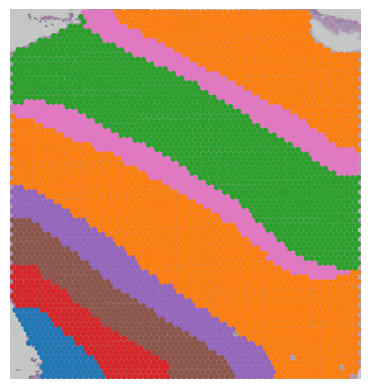

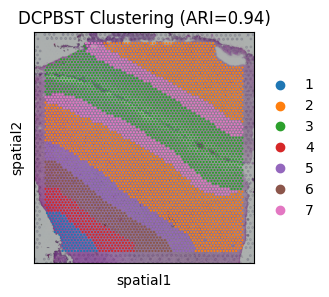

In [ ]:
import sys
import os
os.chdir(REPO_ROOT)
from dcpbst_package.hist_features import get_features
from dcpbst_package.utils import *
from dcpbst_package.model_827_copy import Dcpbst
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as scs
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import random
from dcpbst_package.evals import *
from dcpbst_package.preprocess import *
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import json
from tqdm import tqdm
import networkx as nx
import scipy.sparse as sp
from torch.backends import cudnn
import torchvision.models as models
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.csc import csc_matrix
from scipy.sparse.csr import csr_matrix
import torchvision.transforms as transforms
import cv2
from sklearn.preprocessing import LabelEncoder
import importlib_metadata 
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, \
    homogeneity_completeness_v_measure, calinski_harabasz_score, davies_bouldin_score
seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")

def load_visium_with_labels(path, label_col='layer_guess'):
    adata = sc.read_visium(path, load_images=True)
    adata.var_names_make_unique()

    # Read metadata.tsv as labels
    metadata_path = os.path.join(path, "metadata.tsv")
    if os.path.exists(metadata_path):
        meta_df = pd.read_csv(metadata_path, sep="\t")
        assert label_col in meta_df.columns, f"{label_col} not in metadata.tsv"
        adata.obs["Ground Truth"] = meta_df[label_col].values
    else:
        raise FileNotFoundError("metadata.tsv not found")

    # Remove unlabeled entries
    adata = adata[~pd.isnull(adata.obs["Ground Truth"])]
    return adata

# Image parameters
def extract_scalefactors(path):
    scale_path = os.path.join(path, "spatial", "scalefactors_json.json")
    with open(scale_path, "r") as f:
        scale_info = json.load(f)

    spot_diameter = scale_info["spot_diameter_fullres"]
    hires_scalef = scale_info["tissue_hires_scalef"]
    return spot_diameter, hires_scalef 
# Preprocessing
def preprocess_rna(adata):
    sc.pp.filter_genes(adata,min_cells=10)
    sc.pp.log1p(adata)

    return adata

def preprocess_rna_dlpfc(adata):
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata[:, adata.var['highly_variable']]


# Image feature extraction - ResNet algorithm + preprocessed segmentation
def extract_image_features_resnet(
        adata,
        data_path,
        backbone='ResNet50',
        device='cpu',
        section_id=None,
):
    """Robust image patch extractor.

    Full-resolution TIFF files in this dataset are commonly corrupted on disk
    (bad IFD0 offset). We therefore try multiple loaders:

    1. cv2.imread(full_image.tif)                     [fast — original]
    2. tissue_hires_image.png (with coord scaling)    [fallback]
    3. tissue_lowres_image.png                        [last resort]

    Returns adata with `adata.obsm['feat_img']` populated.
    """
    import json as _json
    import cv2

    if backbone == 'ResNet50':
        img_model = models.resnet50(pretrained=True)
        img_model.to(device)

    spatial_dir = os.path.join(data_path, "spatial")
    scale_path = os.path.join(spatial_dir, "scalefactors_json.json")
    sf = _json.load(open(scale_path)) if os.path.exists(scale_path) else {}

    # ------------------------------------------------------------------
    # 1. Try to load the image + determine working scale factor
    # ------------------------------------------------------------------
    full_image = None
    img_scale = 1.0       # multiplier for adata.obsm["spatial"] pixel coords

    # Option A: full_image.tif via cv2 (original path)
    full_tif = os.path.join(spatial_dir, "full_image.tif")
    if os.path.exists(full_tif):
        _tmp = cv2.imread(full_tif)
        if _tmp is not None:
            full_image = cv2.cvtColor(_tmp, cv2.COLOR_BGR2RGB)
            img_scale = 1.0

    # Option B: tissue_hires_image.png + tissue_hires_scalef
    if full_image is None:
        hires_png = os.path.join(spatial_dir, "tissue_hires_image.png")
        if os.path.exists(hires_png):
            _tmp = cv2.imread(hires_png)
            if _tmp is not None:
                full_image = cv2.cvtColor(_tmp, cv2.COLOR_BGR2RGB)
                img_scale = float(sf.get("tissue_hires_scalef", 1.0))
                print(f"  [fallback] Using tissue_hires_image.png "
                      f"(shape {full_image.shape}, scale={img_scale:.6f})")

    # Option C: lowres
    if full_image is None:
        lowres_png = os.path.join(spatial_dir, "tissue_lowres_image.png")
        _tmp = cv2.imread(lowres_png)
        if _tmp is not None:
            full_image = cv2.cvtColor(_tmp, cv2.COLOR_BGR2RGB)
            img_scale = float(sf.get("tissue_lowres_scalef", 1.0))
            print(f"  [fallback] Using tissue_lowres_image.png "
                  f"(shape {full_image.shape}, scale={img_scale:.6f})")

    if full_image is None:
        raise RuntimeError(
            "Cannot load any tissue image from spatial/. Tried: "
            f"{full_tif}, hires, lowres."
        )

    img_h, img_w = full_image.shape[:2]

    # ------------------------------------------------------------------
    # 2. Patch extraction
    # ------------------------------------------------------------------
    sid = section_id or os.path.basename(os.path.normpath(data_path))
    save_dir = os.path.join(DATA_DIR, f"cut_img_{sid}")
    os.makedirs(save_dir, exist_ok=True)

    cut_path = os.path.join(save_dir, f"cut_img_{sid}.npy")
    feat_path = os.path.join(save_dir, f"Img_feat_{sid}.npy")

    img_size = 224

    if not os.path.exists(cut_path):
        patches = []
        for x_full, y_full in adata.obsm["spatial"]:
            cx = int(round(float(x_full) * img_scale))
            cy = int(round(float(y_full) * img_scale))

            patch = full_image[
                max(0, cy - img_size):cy + img_size,
                max(0, cx - img_size):cx + img_size,
            ]

            # If patch comes out smaller than (2*img_size) pad with zeros
            if patch.shape != (2 * img_size, 2 * img_size, 3):
                padded = np.zeros(
                    (2 * img_size, 2 * img_size, 3), dtype=full_image.dtype
                )
                off_y = 0 if cy - img_size < 0 else 0
                off_x = 0 if cx - img_size < 0 else 0
                start_y = max(img_size - cy, 0)
                start_x = max(img_size - cx, 0)
                dst = padded[
                    start_y:start_y + patch.shape[0],
                    start_x:start_x + patch.shape[1],
                ]
                np.copyto(dst, patch[:dst.shape[0], :dst.shape[1]])
                patch = padded

            patches.append(patch)

        np.save(cut_path, np.array(patches))
        print(f"  Image patches saved: {cut_path}")
    print("cutting image finished!")

    # ------------------------------------------------------------------
    # 3. Image feature extraction via ImageNet ResNet50 (with preprocess)
    # ------------------------------------------------------------------
    assert os.path.exists(cut_path), f"Missing pre-cached patch file: {cut_path}"
    spot_img = np.load(cut_path).astype(np.float32) / 255.0
    tensor = torch.from_numpy(spot_img)

    if not os.path.exists(feat_path):
        img_feat = []
        for element in tqdm(tensor, desc=f"Image features ({sid})"):
            element = element.resize_(1, 3, 224, 224).to(device)
            ret = img_model(element)
            img_feat.append(ret.data.cpu().numpy().ravel())
        np.save(feat_path, np.array(img_feat))
        img_feat = np.array(img_feat)
    else:
        img_feat = np.load(feat_path)

    print("the image feature has been extracted!")
    adata.obsm["feat_img"] = img_feat
    return adata

def extract_image_features(data_path, pixel_size=0.5, device='cuda', adata=None):
    from PIL import Image
    import pandas as pd
    import numpy as np
    import json
    import os

    full_image_path = os.path.join(data_path, "spatial", "full_image.tif")
    im = Image.open(full_image_path)

    locs_path = os.path.join(data_path, "spatial", "tissue_positions_list.csv")
    locs = pd.read_csv(locs_path, index_col=0)
    locs.columns = [str(i) for i in range(1, 6)]

    # Add this code: ensure locs align with adata
    if adata is not None:
        locs = locs.loc[adata.obs_names]

    # Load scalefactor
    scale_path = os.path.join(data_path, "spatial", "scalefactors_json.json")
    with open(scale_path, "r") as f:
        scalefactors = json.load(f)
    spot_diameter = scalefactors["spot_diameter_fullres"]
    pixel_size_raw = 55 / spot_diameter
    rad = 55 / (2 * pixel_size_raw)

    image_emb = get_features(im, locs, rad, pixel_size_raw, pixel_size, pretrained=True, device=device)

    return image_emb, locs
def purity_score(y_true, y_pred):
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)


def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01):
    print('Searching resolution...')
    label = 0
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in sorted(list(np.arange(start, end, increment)), reverse=True):
        if method == 'leiden':
            sc.tl.leiden(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['leiden']).leiden.unique())
            print('resolution={}, cluster number={}'.format(res, count_unique))
        elif method == 'louvain':
            sc.tl.louvain(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['louvain']).louvain.unique())
            print('resolution={}, cluster number={}'.format(res, count_unique))
        if count_unique == n_clusters:
            label = 1
            break

    assert label == 1, "Resolution is not found. Please try bigger range or smaller step!."

    return res

# 2. Define clustering-related metric calculation
def refine_label(adata, radius=50, key='label'):
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values

    # calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')

    n_cell = distance.shape[0]

    for i in range(n_cell):
        vec = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh + 1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)

    new_type = [str(i) for i in list(new_type)]

    return new_type


def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2024):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    print(res)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    return adata

def calculate_clustering_matrix(df, y_pred, ground_truth):
    ari = adjusted_rand_score(y_pred, ground_truth)
    nmi = normalized_mutual_info_score(y_pred, ground_truth)
    purity = purity_score(y_pred, ground_truth)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_pred, ground_truth)
    print("ARI={}, NMI={},Purity={},V_Measure={}".format(ari, nmi,purity,v_measure))

    new_row = pd.DataFrame([{
        'ARI': ari,
        'NMI': nmi,
        'Purity': purity,
        'Homogeneity': homogeneity,
        'Completeness': completeness,
        'V_Measure': v_measure
        # 'Sample' and 'methods' columns can be added later or adjusted as needed
    }])

    # 2. Use pd.concat to merge new rows into existing DataFrame
    df = pd.concat([df, new_row], ignore_index=True)
    
    return df
def clustering(adata, n_clusters=7, radius=50, key='emb', method='mclust', start=0.1, end=3.0, increment=0.01,
               refinement=False):# Changed a parameter setting
    # PCA dimensionality reduction done before clustering
    pca = PCA(n_components=20, random_state=2024)
    embedding = pca.fit_transform(adata.obsm[key].copy())
    adata.obsm['emb_pca'] = embedding


    if method == 'mclust':
        adata = mclust_R(adata, used_obsm='emb_pca', num_cluster=n_clusters)
        adata.obs['domain'] = adata.obs['mclust']
    elif method == 'kmeans':
        kmeans = KMeans(n_clusters=n_clusters).fit(embedding)
        kmeans_result = [i + 1 for i in kmeans.labels_]
        adata.obs['domain'] = list(map(lambda x: str(x), kmeans_result))
    elif method == 'leiden':
        res = search_res(adata, n_clusters, use_rep='emb_pca', method=method, start=start, end=end, increment=increment)
        sc.tl.leiden(adata, random_state=0, resolution=res)
        adata.obs['domain'] = adata.obs['leiden']
    elif method == 'louvain':
        res = search_res(adata, n_clusters, use_rep='emb_pca', method=method, start=start, end=end, increment=increment)
        sc.tl.louvain(adata, random_state=0, resolution=res)
        adata.obs['domain'] = adata.obs['louvain']

    if refinement:
        new_type = refine_label(adata, radius, key='domain')
        adata.obs['domain'] = new_type



# Main execution function
# --------------------------
# Result caching: trained embedding + clusters are saved to h5ad so that
# reruns skip model training automatically. Set FORCE_RETRAIN = True
# (or delete the h5ad in saved_results/) to retrain from scratch.
# --------------------------
CACHE_TAG = 'DLPFC_151509'
FORCE_RETRAIN = False
ADATA_SAVE_PATH = os.path.join(RESULTS_DIR, f'dcpbst_{CACHE_TAG}_adata_with_clusters.h5ad')
MODEL_SAVE_PATH = os.path.join(RESULTS_DIR, f'dcpbst_{CACHE_TAG}_model.pth')
EVAL_DF_SAVE_PATH = os.path.join(RESULTS_DIR, f'dcpbst_{CACHE_TAG}_clustering_metrics.csv')


def run_dcpbst_pipeline(data_path, device='cuda', label_col='layer_guess', section_id='151509', save_csv=True):
    # ----- Cached results: skip retraining when a saved h5ad exists -----
    if os.path.exists(ADATA_SAVE_PATH) and not FORCE_RETRAIN:
        print(f"\u2705 Found cached results: {ADATA_SAVE_PATH}")
        print("   Skipping model training; loading saved embedding + clusters.")
        print("   (Set FORCE_RETRAIN = True above or delete the file to retrain.)")
        _cached_adata = sc.read_h5ad(ADATA_SAVE_PATH)
        _cached_df = pd.read_csv(EVAL_DF_SAVE_PATH) if os.path.exists(EVAL_DF_SAVE_PATH) else pd.DataFrame()
        return _cached_adata, None, _cached_df


    df = pd.DataFrame(columns=['Sample', 'ARI', 'NMI', 'Purity', 'Homogeneity', 'Completeness', 'V_Measure', 'methods'])
    adata = load_visium_with_labels(data_path, label_col)
    print(f"Loaded data: {adata.shape}")
    adata = preprocess_rna_dlpfc(adata)
    if scipy.sparse.issparse(adata.X):
        scrna=adata.X.A
    else:
        scrna=adata.X
    print("scrna shape:", scrna.shape)

    if 'feat_img' not in adata.obsm.keys():
        extract_image_features_resnet(adata, data_path=data_path,device=device)# #Geteach spotPlotimage features
    image_emb=adata.obsm['feat_img']
    print("image_emb shape:", image_emb.shape)
    n_clusters=len(set(adata.obs["Ground Truth"]))
    print(n_clusters)
    model = Dcpbst([scrna,image_emb],sparse=False,device=device,n_clusters=n_clusters,adata=adata,neighbors=7)
    
    embedding=model.fit()
    adata.obsm['emb']=embedding
    adata.obsm['emb1']=embedding

# 3. Pass it into the clustering method
    radius = 50
    tool = 'mclust'
    if tool == 'mclust':
        clustering(adata, n_clusters=n_clusters, radius=radius, method=tool,
                   refinement=True)  # For DLPFC dataset, we use optional refinement step.
    elif tool == 'kmeans':
        clustering(adata, n_clusters=n_clusters, method=tool)
    elif tool in ['leiden', 'louvain']:
        clustering(adata, n_clusters=n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01,
                   refinement=True)
    df = calculate_clustering_matrix(df, adata.obs['domain'], adata.obs['Ground Truth'])
    print(df)
    df.to_csv('DLPFC-0660.csv')

    pca = PCA(n_components=20, random_state=2024)
    embedding1 = pca.fit_transform(adata.obsm['emb1'].copy())
    adata.obsm['emb1_pca'] = embedding1
    # ----- Cache trained embedding + clusters so reruns skip training -----
    os.makedirs(RESULTS_DIR, exist_ok=True)
    adata.write_h5ad(ADATA_SAVE_PATH)
    print(f"\u2705 adata (with trained embedding) saved: {ADATA_SAVE_PATH}")
    df.to_csv(EVAL_DF_SAVE_PATH, index=False)
    print(f"\u2705 clustering metrics saved: {EVAL_DF_SAVE_PATH}")
    try:
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\u2705 model state_dict saved: {MODEL_SAVE_PATH}")
    except Exception as _save_err:
        print(f"\u26a0\ufe0f model state_dict not saved: {_save_err}")


    return adata, model, df

adata, model, eval_df = run_dcpbst_pipeline(os.path.join(DATA_DIR, '151509'), device='cuda')

final_clusters = adata.obs['domain']

# 2. Get list and count of unique categories
unique_clusters = final_clusters.unique()
num_final_clusters = len(unique_clusters)

print(f"List of unique categories in final clustering results: {sorted(unique_clusters)}")
print(f"Total number of categories in final clustering results: {num_final_clusters}")

print("\nCell count statistics for each cluster:")
print(final_clusters.value_counts())

data_path=os.path.join(DATA_DIR, '151509')
# Write visualization-related code:
locs_path = os.path.join(data_path, "spatial", "tissue_positions_list.csv")
locs = pd.read_csv(locs_path, header=None, index_col=0)
locs.columns = ['in_tissue', 'array_row', 'array_col', '4', '5']

locs = locs.loc[adata.obs_names]

# 3. Get clustering results
clusters = adata.obs['domain'].astype(int).values

# 4. Read tissue image
im = plt.imread(os.path.join(data_path, "spatial", "tissue_hires_image.png"))
# 5. Get scaling factor
with open(os.path.join(data_path, "spatial", "scalefactors_json.json"), "r") as f:
    scalefactors = json.load(f)
scale = scalefactors["tissue_hires_scalef"] 
# 6. Visualization
plot_on_histology(clusters, locs, im, scale, s=10)



print("\n--- Visualizing DCPBST Clustering Result with scanpy ---")

# --- Data preparation ---
# Extract ARI score for title
try:
    ari_score = eval_df['ARI'].iloc[0]
except:
    ari_score = 0.0
print(adata)

# Define column name for clustering results
plt.rcParams["figure.figsize"] = (3,3)

sc.pl.spatial(
    adata,
    # <<< Modified: color parameter only provides a column name string >>>
    color="domain",
    # <<< Modified: title parameter also only provides a title string >>>
    title=f'DCPBST Clustering (ARI={ari_score:.2f})',
)









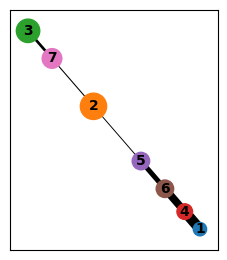

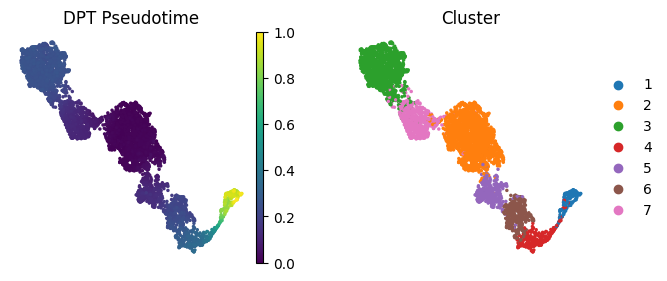

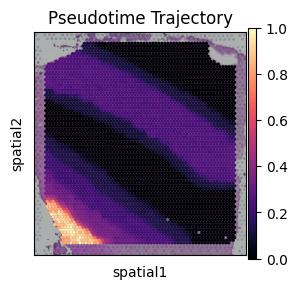

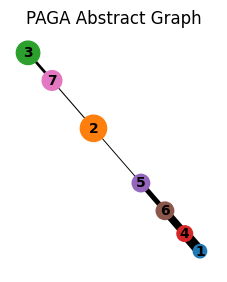

In [3]:
import scanpy as sc
import numpy as np

# -----------------------------
# Step 0: Parameter settings
# -----------------------------
embedding_key = 'emb1_pca'              # Embedding space for plotting
cluster_key = 'domain'        # clustersResult column
paga_group_col = 'paga_group'               # PAGA Grouping column
spot_size = 150

# -----------------------------
# Step 1: Build adjacency graph + Set DPT Starting point
# -----------------------------
sc.pp.neighbors(adata, use_rep=embedding_key, n_neighbors=10)

adata.uns["iroot"] = np.flatnonzero(adata.obs[cluster_key] == "2")[10]

# -----------------------------
# Step 2: Calculate DPT Pseudotime
# -----------------------------
sc.tl.dpt(adata)

# -----------------------------
# Step 3: Build PAGA Plot
# -----------------------------
# PAGA group must be string
adata.obs[paga_group_col] = adata.obs[cluster_key].astype(str)

sc.tl.paga(adata, groups=paga_group_col)

# -----------------------------
# Step 4: Use PAGA Initialization UMAP
# -----------------------------
sc.pl.paga(adata, show=False)
sc.tl.umap(adata, init_pos='paga')

# -----------------------------
# Step 5: Visualization results
# -----------------------------

sc.pl.umap(
    adata,
    color=["dpt_pseudotime", cluster_key],
    title=["DPT Pseudotime", "Cluster"],
    frameon=False
)
if 'ground_truth' in adata.obs.columns:
    sc.pl.umap(
        adata,
        color="ground_truth", # <-- Corrected spelling
        title="Ground Truth",  # <-- Corrected to a single string
        frameon=False
    )
sc.pl.spatial(
    adata,
    color=["dpt_pseudotime"],
    cmap="magma",
    spot_size=spot_size,
    title="Pseudotime Trajectory"
)

sc.pl.paga(
    adata,
    color=paga_group_col,
    title="PAGA Abstract Graph",
    frameon=False
)
